# Receiver Operating Characteristic

* Una métria esencial para clasificadores.
* En español realmente no significa mucho, algo como Caracteristica Operativa del receptor.
* Está metrica esa muy relacionada con los radares.
* Esta métrica solo puede aplicar para clasificadores binarios.
* Si estás en la clase roja, pudiera ser que tienes una enfermedad y si estas en la azul son pacientes sanos.
* Hay otra metrica de esta pero para multiclases.
* Cómo casi no hay error nulos, es decir, del 0%, existe una categoría llamaba "Zona NO Concluyente". Es decir, que para los clasificadores sea muy dificil diferenciar, ya que podría tener caracteristicas de ambas.
* Los valores que quedan en dicha zona serán considerados falsos positivos y Verdaderos Negativos.
![ROC](ROC.png)

* Podemos establecer un punto de corte (***UMBRAL***), esto con lo que nosayuda es a eliminar ciertos puntos de consideración para ya sea Falsos Positivos o Falsos Negativos.
  
![UMBRA](UMBRAL.png)

![Comparacion](Comparacion.png)

### ¿Qué es la curva ROC?

* La curva ROC es una gráfica que muestra el rendimiento de un clasificador binario a medida que varía su umbral de decisión. En el eje x se representa la tasa de falsos positivos (FPR) y en el eje y la tasa de verdaderos positivos (TPR).
  
![Tasas](Tasas.png)

### ¿Cómo se construye la curva ROC?

1. Se calculan las probabilidades (o scores) del modelo para cada observación.
2. Se elige un umbral, por ejemplo 0.5, y se clasifican los ejemplos como positivos o negativos.
3. Se calcula el par (FPR,TPR).
4. Se repite el proceso variando el umbral desde 0 hasta 1.
5. Se grafican todos los pares en el plano ROC.
6. El resultado es una curva que parte de (0,0) y termina en (1,1). 

### AUC – Área Bajo la Curva

* El AUC (Area Under the Curve) resume la curva ROC en un solo número entre 0 y 1. Cuanto más cerca de 1, mejor el modelo. Se interpreta como la probabilidad de que el modelo asigne una mayor puntuación a una instancia positiva que a una negativa.
* Interpretación del AUC
  - AUC = 1.0: Clasificador perfecto.
  - AUC = 0.5: Sin poder de clasificación (equivalente a un clasificador aleatorio).
  - AUC < 0.5: Peor que aleatorio (el modelo invierte los resultados).

### Ejemplo Manual

* Supongamos que tenemos este pequeño conjunto de datos con 4 instancias, cada una con su etiqueta real (0 o 1) y la probabilidad de clase positiva que da el modelo.

| ID | Etiqueta Real (y) | Probabilidad Predicha (p) |
| -- | ----------------- | ------------------------- |
| A  | 1                 | 0.9                       |
| B  | 0                 | 0.8                       |
| C  | 1                 | 0.7                       |
| D  | 0                 | 0.4                       |


* Paso 1: Ordenar las instancias por probabilidad descendente

| ID | y | p   |
| -- | - | --- |
| A  | 1 | 0.9 |
| B  | 0 | 0.8 |
| C  | 1 | 0.7 |
| D  | 0 | 0.4 |


* Paso 2: Calcular TPR y FPR para distintos umbrales
  - Para cada umbral, clasificamos los ejemplos como positivos si su probabilidad ≥ umbral.
  - Vamos a probar umbrales: 1.0, 0.9, 0.8, 0.7, 0.4, 0.0

* Total de positivos reales (P): 2 (A y C)
* Total de negativos reales (N): 2 (B y D)

| Umbral | TP | FP | FN | TN | TPR = TP / P | FPR = FP / N |
| ------ | -- | -- | -- | -- | ------------ | ------------ |
| 1.0    | 0  | 0  | 2  | 2  | 0.00         | 0.00         |
| 0.9    | 1  | 0  | 1  | 2  | 0.50         | 0.00         |
| 0.8    | 1  | 1  | 1  | 1  | 0.50         | 0.50         |
| 0.7    | 2  | 1  | 0  | 1  | 1.00         | 0.50         |
| 0.4    | 2  | 2  | 0  | 0  | 1.00         | 1.00         |
| 0.0    | 2  | 2  | 0  | 0  | 1.00         | 1.00         |


* Paso 3: Coordenadas de la curva ROC
* Los puntos que forman la curva ROC son:
  - (0.00,0.00)
  - (0.00,0.50)
  - (0.50,0.50)
  - (0.50,1.00)
  - (1.00,1.00)

* Paso 4: Cálculo del AUC
* El AUC es el área bajo esta curva. Aquí se puede calcular como suma de áreas de trapecios entre cada par de puntos. Puedes usar la fórmula:

$$
\text{AUC} = \sum_{i=1}^{n-1} (FPR_{i+1} - FPR_i) \cdot \frac{TPR_{i+1} + TPR_i}{2}
$$

* Aplicando eso para los puntos:
  - De (0, 0) a (0, 0.5) → área = 0
  - De (0, 0.5) a (0.5, 0.5) → área = 0.5 ⋅ 0.5 = 0.25
  - De (0.5, 0.5) a (0.5, 1.0) → área = 0
  - De (0.5, 1.0) a (1.0, 1.0) → área = 0.5 ⋅ 1.0 = 0.5
  - Total AUC = 0 + 0.25 + 0 + 0.5 = 0.75

###  Código en Python (con sklearn)

FPR: [0.  0.  0.5 0.5 1. ]
TPR: [0.  0.5 0.5 1.  1. ]
Umbrales: [inf 0.9 0.8 0.7 0.4]
AUC: 0.75


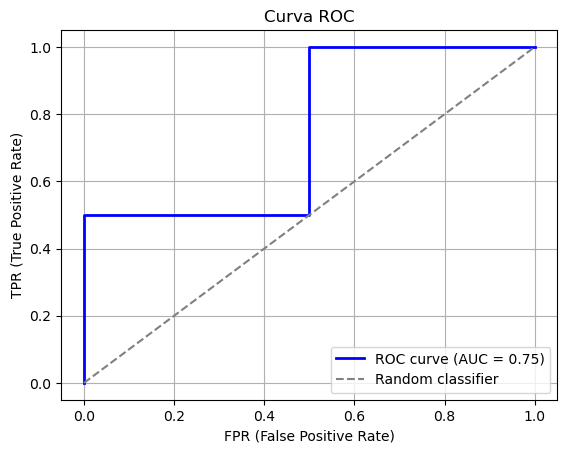

In [2]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Etiquetas reales
y_true = [1, 0, 1, 0]

# Probabilidades predichas por el modelo
y_scores = [0.9, 0.8, 0.7, 0.4]

# Calculamos TPR y FPR para todos los umbrales
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculamos el AUC
roc_auc = auc(fpr, tpr)

# Mostramos resultados
print("FPR:", fpr)
print("TPR:", tpr)
print("Umbrales:", thresholds)
print("AUC:", roc_auc)

# Graficamos la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid()
plt.show()
